<a href="https://colab.research.google.com/github/mittaldevansh/Collab-Files/blob/main/LAB_3_4_Bias_Detection_Loan_Approval_Colab_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB 3–4: Bias Detection in Loan Approval

**Tool focus:** Google Colab fairness analysis workflow  
**Original tool reference:** Google What-If Tool  
**Outcome:** Students understand fairness in AI by comparing loan approval rates across **Gender**.

> Important: This notebook intentionally avoids the Google What-If Tool widget because many Colab sessions show the error:  
> `await connected: disconnected`  
> This happens due to Colab + WIT widget/library compatibility issues.  
> Instead, this notebook uses stable Python, Pandas, Matplotlib, and Scikit-learn methods to teach the same fairness concept clearly.

In [ ]:
# CELL 1: Import required libraries
# These libraries are stable in Google Colab and do not depend on the WIT widget.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# CELL 2: Upload the dataset safely in Colab
# Run this cell and upload: loan_bias_dataset_100_rows.csv
# This upload method avoids Google What-If Tool widget errors.

from google.colab import files

uploaded = files.upload()

print("Uploaded files:", list(uploaded.keys()))

Saving loan_bias_dataset_100_rows.csv to loan_bias_dataset_100_rows.csv
Uploaded files: ['loan_bias_dataset_100_rows.csv']


In [ ]:
# CELL 3: Load the uploaded dataset automatically
# The notebook looks for loan_bias_dataset_100_rows.csv.
# If the file name is slightly different, it loads the first uploaded CSV file.

import os

expected_file = "loan_bias_dataset_100_rows.csv"

if os.path.exists(expected_file):
    DATA_FILE = expected_file
else:
    csv_files = [file for file in os.listdir() if file.endswith(".csv")]
    if len(csv_files) == 0:
        raise FileNotFoundError("No CSV file found. Please run CELL 2 and upload the dataset.")
    DATA_FILE = csv_files[0]

print("Dataset loaded from:", DATA_FILE)

df = pd.read_csv(DATA_FILE)
df.head()

Dataset loaded from: loan_bias_dataset_100_rows.csv


,Loan_ID,Gender,Age,Married,Dependents,Education,ApplicantIncome,CoapplicantIncome,TotalIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP0001,Male,30,No,1,Graduate,60000,10000,70000,1250000,180,1,Rural,Approved
1,LP0002,Female,57,No,0,Graduate,27500,5000,32500,400000,180,1,Rural,Approved
2,LP0003,Male,24,No,1,Graduate,95000,45000,140000,500000,180,1,Urban,Approved
3,LP0004,Female,50,No,1,Not Graduate,57500,60000,117500,600000,180,1,Urban,Approved
4,LP0005,Male,47,No,2,Graduate,120000,20000,140000,1350000,180,1,Rural,Approved


In [ ]:
# CELL 4: Check dataset shape and columns
# This helps students understand what data is available for bias analysis.

print("Rows and columns:", df.shape)
print("Column names:")
print(df.columns.tolist())

Rows and columns: (100, 14)
Column names:
['Loan_ID', 'Gender', 'Age', 'Married', 'Dependents', 'Education', 'ApplicantIncome', 'CoapplicantIncome', 'TotalIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [ ]:
# CELL 5: Preview basic information
# We check data types and missing values before analysis.

print("Dataset information:")
df.info()

print("\nMissing values in each column:")
print(df.isnull().sum())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Loan_ID            100 non-null    object
 1   Gender             100 non-null    object
 2   Age                100 non-null    int64 
 3   Married            100 non-null    object
 4   Dependents         100 non-null    int64 
 5   Education          100 non-null    object
 6   ApplicantIncome    100 non-null    int64 
 7   CoapplicantIncome  100 non-null    int64 
 8   TotalIncome        100 non-null    int64 
 9   LoanAmount         100 non-null    int64 
 10  Loan_Amount_Term   100 non-null    int64 
 11  Credit_History     100 non-null    int64 
 12  Property_Area      100 non-null    object
 13  Loan_Status        100 non-null    object
dtypes: int64(8), object(6)
memory usage: 11.1+ KB

Missing values in each column:
Loan_ID              0
Gender           

In [ ]:
# CELL 6: Standardize the target column
# Loan_Status is converted into a numeric approval label:
# Approved = 1
# Rejected = 0

approval_map = {
    "Approved": 1,
    "Rejected": 0,
    "Y": 1,
    "N": 0,
    1: 1,
    0: 0
}

df["Loan_Approved"] = df["Loan_Status"].map(approval_map)

if df["Loan_Approved"].isnull().any():
    raise ValueError("Some Loan_Status values could not be mapped. Please check the unique values.")

print(df[["Loan_Status", "Loan_Approved"]].head())
print("\nTarget distribution:")
print(df["Loan_Approved"].value_counts())

  Loan_Status  Loan_Approved
0    Approved              1
1    Approved              1
2    Approved              1
3    Approved              1
4    Approved              1

Target distribution:
Loan_Approved
1    66
0    34
Name: count, dtype: int64


Gender distribution:
Gender
Male      51
Female    49
Name: count, dtype: int64


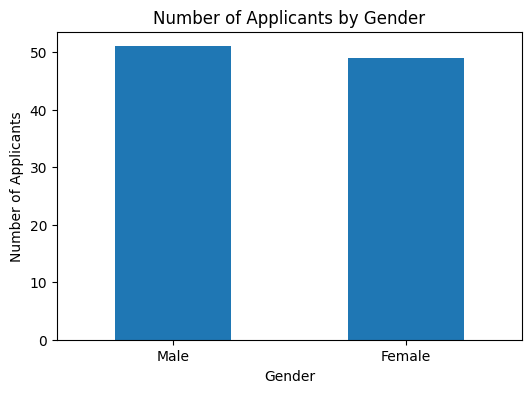

In [ ]:
# CELL 7: Check Gender distribution
# This tells us how many Male and Female applicants are present in the dataset.

print("Gender distribution:")
print(df["Gender"].value_counts())

plt.figure(figsize=(6,4))
df["Gender"].value_counts().plot(kind="bar")
plt.title("Number of Applicants by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# CELL 8: Calculate approval rate by Gender
# Approval rate = Number of approved applicants / Total applicants in that gender group

approval_by_gender = (
    df.groupby("Gender")["Loan_Approved"]
      .agg(Applicants="count", Approved="sum", Approval_Rate="mean")
      .reset_index()
)

approval_by_gender["Approval_Rate_Percentage"] = approval_by_gender["Approval_Rate"] * 100
approval_by_gender

,Gender,Applicants,Approved,Approval_Rate,Approval_Rate_Percentage
0,Female,49,29,0.591837,59.183673
1,Male,51,37,0.725490,72.549020


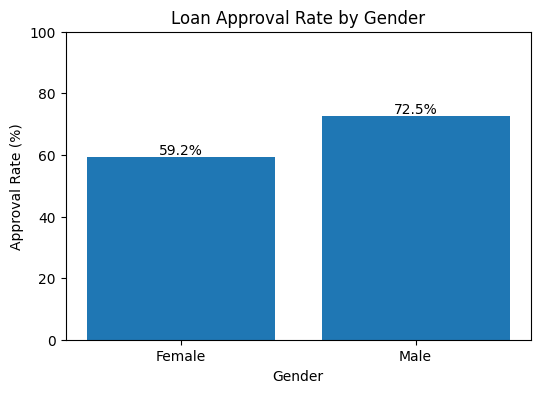

In [ ]:
# CELL 9: Visualize approval rate by Gender
# This is the key fairness comparison for the lab.

plt.figure(figsize=(6,4))
plt.bar(
    approval_by_gender["Gender"],
    approval_by_gender["Approval_Rate_Percentage"]
)
plt.title("Loan Approval Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Approval Rate (%)")
plt.ylim(0, 100)

for index, value in enumerate(approval_by_gender["Approval_Rate_Percentage"]):
    plt.text(index, value + 1, f"{value:.1f}%", ha="center")

plt.show()

In [ ]:
# CELL 10: Calculate fairness gap
# Fairness gap shows the difference between the highest and lowest approval rates.

max_rate = approval_by_gender["Approval_Rate_Percentage"].max()
min_rate = approval_by_gender["Approval_Rate_Percentage"].min()
fairness_gap = max_rate - min_rate

print(f"Highest approval rate: {max_rate:.2f}%")
print(f"Lowest approval rate: {min_rate:.2f}%")
print(f"Fairness gap: {fairness_gap:.2f} percentage points")

if fairness_gap < 5:
    print("Interpretation: The approval-rate difference is low in this dataset.")
elif fairness_gap < 15:
    print("Interpretation: There may be moderate difference. Further investigation is needed.")
else:
    print("Interpretation: There may be a strong fairness concern. Further investigation is needed.")

Highest approval rate: 72.55%
Lowest approval rate: 59.18%
Fairness gap: 13.37 percentage points
Interpretation: There may be moderate difference. Further investigation is needed.


In [ ]:
# CELL 11: Compare approval counts by Gender
# This shows both approved and rejected applicants for each gender group.

approval_counts = pd.crosstab(df["Gender"], df["Loan_Status"])
approval_counts

Loan_Status,Approved,Rejected
Gender,,
Female,29,20
Male,37,14


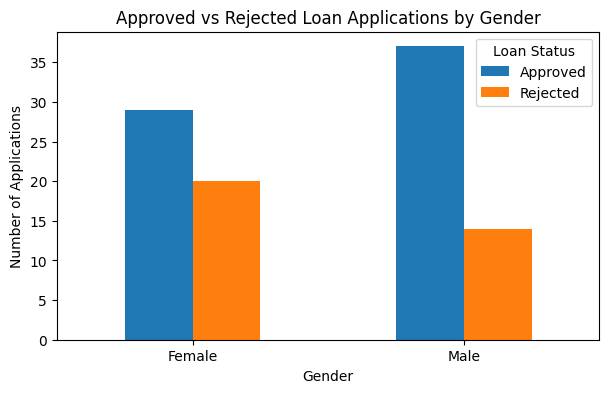

In [ ]:
# CELL 12: Visualize approved vs rejected counts
# This chart helps students compare actual numbers, not only percentages.

approval_counts.plot(kind="bar", figsize=(7,4))
plt.title("Approved vs Rejected Loan Applications by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Applications")
plt.xticks(rotation=0)
plt.legend(title="Loan Status")
plt.show()

In [ ]:
# CELL 13: Prepare features for a simple loan approval model
# We remove identifiers and target columns.
# Gender is kept here so students can observe model fairness behavior.

X = df.drop(columns=["Loan_ID", "Loan_Status", "Loan_Approved"])
y = df["Loan_Approved"]

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

Categorical features: ['Gender', 'Married', 'Education', 'Property_Area']
Numeric features: ['Age', 'Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'TotalIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


In [ ]:
# CELL 14: Build a simple Logistic Regression pipeline
# OneHotEncoder converts categorical columns like Gender, Married, Education, and Property_Area into numeric form.

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

print("Model pipeline created successfully.")

Model pipeline created successfully.


In [ ]:
# CELL 15: Train-test split and model training
# Stratify keeps the approval/rejection ratio similar in train and test data.
# This cell avoids the WIT widget completely, so the Colab connection error should not occur.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model.fit(X_train, y_train)

print("Model trained successfully.")
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Model trained successfully.
Training rows: 75
Testing rows: 25


In [ ]:
# CELL 16: Evaluate the model
# Accuracy tells us how often the model predicted correctly.
# But fairness analysis needs group-wise comparison, not only accuracy.

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.76
Confusion Matrix:
[[ 4  4]
 [ 2 15]]
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.50      0.57         8
           1       0.79      0.88      0.83        17

    accuracy                           0.76        25
   macro avg       0.73      0.69      0.70        25
weighted avg       0.75      0.76      0.75        25



In [ ]:
# CELL 17: Create a test-results table for fairness analysis
# We compare actual and predicted approval rates across Gender.

test_results = X_test.copy()
test_results["Actual_Approval"] = y_test.values
test_results["Predicted_Approval"] = y_pred

test_results.head()

,Gender,Age,Married,Dependents,Education,ApplicantIncome,CoapplicantIncome,TotalIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Actual_Approval,Predicted_Approval
16,Male,39,Yes,2,Graduate,125000,40000,165000,1050000,180,1,Urban,1,1
2,Male,24,No,1,Graduate,95000,45000,140000,500000,180,1,Urban,1,1
90,Male,23,No,0,Graduate,32500,42500,75000,550000,360,1,Urban,1,1
29,Female,49,No,1,Not Graduate,87500,2500,90000,350000,240,0,Urban,0,0
6,Male,46,Yes,0,Graduate,60000,60000,120000,550000,180,1,Urban,1,1


In [ ]:
# CELL 18: Compare actual approval rate and model-predicted approval rate by Gender
# This shows whether the model predictions differ across gender groups.

fairness_model_comparison = (
    test_results.groupby("Gender")
    .agg(
        Test_Applicants=("Predicted_Approval", "count"),
        Actual_Approval_Rate=("Actual_Approval", "mean"),
        Predicted_Approval_Rate=("Predicted_Approval", "mean")
    )
    .reset_index()
)

fairness_model_comparison["Actual_Approval_Rate_%"] = fairness_model_comparison["Actual_Approval_Rate"] * 100
fairness_model_comparison["Predicted_Approval_Rate_%"] = fairness_model_comparison["Predicted_Approval_Rate"] * 100

fairness_model_comparison

,Gender,Test_Applicants,Actual_Approval_Rate,Predicted_Approval_Rate,Actual_Approval_Rate_%,Predicted_Approval_Rate_%
0,Female,10,0.5,0.800000,50.0,80.000000
1,Male,15,0.8,0.733333,80.0,73.333333


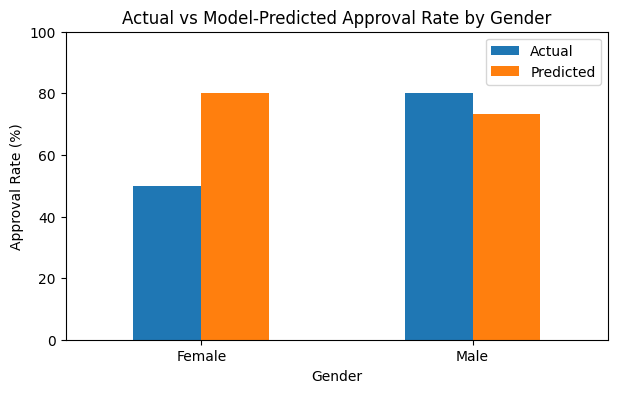

In [ ]:
# CELL 19: Visualize actual vs predicted approval rates by Gender
# This gives a What-If-Tool-like comparison using stable Python charts.

plot_df = fairness_model_comparison.set_index("Gender")[[
    "Actual_Approval_Rate_%",
    "Predicted_Approval_Rate_%"
]]

plot_df.plot(kind="bar", figsize=(7,4))
plt.title("Actual vs Model-Predicted Approval Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Approval Rate (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(["Actual", "Predicted"])
plt.show()

In [ ]:
# CELL 20: Student reflection questions
# These questions help connect practical output with fairness concepts.

questions = [
    "1. Which gender group has a higher approval rate in the original dataset?",
    "2. What is the approval-rate gap between gender groups?",
    "3. Does the model predict approvals equally across gender groups?",
    "4. Is accuracy alone enough to judge whether the model is fair? Why or why not?",
    "5. What other features should be checked before concluding that the model is biased?"
]

for question in questions:
    print(question)

1. Which gender group has a higher approval rate in the original dataset?
2. What is the approval-rate gap between gender groups?
3. Does the model predict approvals equally across gender groups?
4. Is accuracy alone enough to judge whether the model is fair? Why or why not?
5. What other features should be checked before concluding that the model is biased?


In [ ]:
# CELL 21: Final lab conclusion template
# Students can edit this conclusion after observing their results.

print("LAB CONCLUSION")
print("--------------")
print("In this lab, we compared loan approval rates across Gender.")
print("We calculated approval percentages, visualized group differences, and trained a simple model.")
print("We learned that AI fairness cannot be judged only by accuracy.")
print("Fairness requires checking whether different groups receive similar or very different outcomes.")
print("This notebook avoids the Google What-If Tool connection issue by using stable Python-based fairness analysis.")

LAB CONCLUSION
--------------
In this lab, we compared loan approval rates across Gender.
We calculated approval percentages, visualized group differences, and trained a simple model.
We learned that AI fairness cannot be judged only by accuracy.
Fairness requires checking whether different groups receive similar or very different outcomes.
This notebook avoids the Google What-If Tool connection issue by using stable Python-based fairness analysis.
